<a href="https://colab.research.google.com/github/Mohammad-Arish-Khan/ml-assignments/blob/main/ML_Exp_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (20640, 8)
Target Shape: (20640,)
Training samples: 16512
Testing samples: 4128

--- Normal Equation ---
MSE: 0.5558915986952424
R2 Score: 0.5757877060324523

--- Gradient Descent ---
MSE: 0.554579506530855
R2 Score: 0.5767889905063641

--- Scikit-learn Linear Regression ---
MSE: 0.5558915986952442
R2 Score: 0.575787706032451

--- Ridge Regression ---
MSE: 0.5558548589435974
R2 Score: 0.575815742891368

--- Lasso Regression ---
MSE: 0.5482548967938964
R2 Score: 0.5816154300698727

MODEL COMPARISON
Normal Equation       MSE = 0.5559   R2 = 0.5758
Gradient Descent      MSE = 0.5546   R2 = 0.5768
Linear Regression     MSE = 0.5559   R2 = 0.5758
Ridge Regression      MSE = 0.5559   R2 = 0.5758
Lasso Regression      MSE = 0.5483   R2 = 0.5816


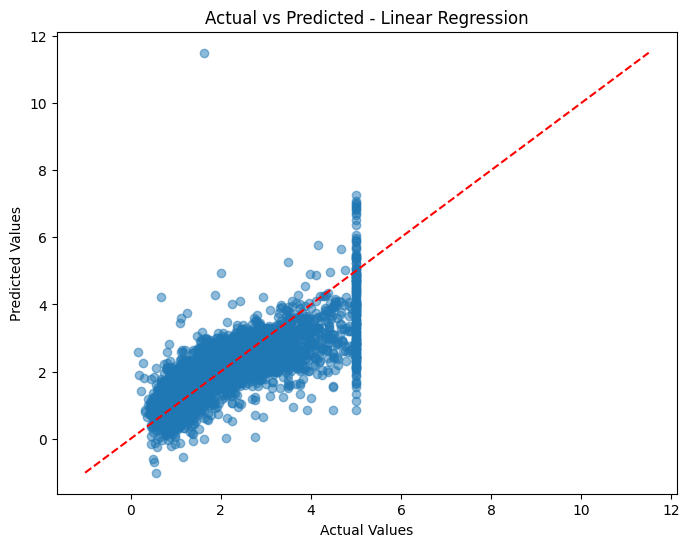


Linear Regression Coefficients:
[ 0.85438303  0.12254624 -0.29441013  0.33925949 -0.00230772 -0.0408291
 -0.89692888 -0.86984178]

Ridge Coefficients:
[ 0.85432679  0.12262397 -0.29421036  0.33900794 -0.00228221 -0.04083302
 -0.89616759 -0.86907074]

Lasso Coefficients:
[ 0.80095744  0.12708701 -0.16275931  0.20620745 -0.         -0.03060176
 -0.79011254 -0.75567379]


In [2]:
# Lab Experiment 1: Linear Regression and Regularization

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score


# ---------------------------------------------------------
# 1. Load California Housing Dataset
# ---------------------------------------------------------

data = fetch_california_housing()

X = data.data
y = data.target

print("Dataset Shape:", X.shape)
print("Target Shape:", y.shape)


# ---------------------------------------------------------
# 2. Split Dataset into Training and Testing
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


# ---------------------------------------------------------
# 3. Feature Scaling
# ---------------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# =========================================================
# 4. LINEAR REGRESSION USING NORMAL EQUATION
# =========================================================

# Add column of 1s for intercept
X_train_bias = np.c_[np.ones(X_train_scaled.shape[0]), X_train_scaled]
X_test_bias = np.c_[np.ones(X_test_scaled.shape[0]), X_test_scaled]

# Normal Equation:
# theta = (X^T X)^(-1) X^T y

theta = np.linalg.pinv(
    X_train_bias.T @ X_train_bias
) @ X_train_bias.T @ y_train

# Predictions
y_pred_normal = X_test_bias @ theta

mse_normal = mean_squared_error(y_test, y_pred_normal)
r2_normal = r2_score(y_test, y_pred_normal)

print("\n--- Normal Equation ---")
print("MSE:", mse_normal)
print("R2 Score:", r2_normal)


# =========================================================
# 5. LINEAR REGRESSION USING GRADIENT DESCENT
# =========================================================

# Initialize parameters
theta_gd = np.zeros(X_train_bias.shape[1])

learning_rate = 0.01
iterations = 1000

m = len(y_train)

for i in range(iterations):

    # Predictions
    predictions = X_train_bias @ theta_gd

    # Error
    error = predictions - y_train

    # Gradient
    gradients = (2 / m) * X_train_bias.T @ error

    # Update parameters
    theta_gd = theta_gd - learning_rate * gradients


# Predictions
y_pred_gd = X_test_bias @ theta_gd

mse_gd = mean_squared_error(y_test, y_pred_gd)
r2_gd = r2_score(y_test, y_pred_gd)

print("\n--- Gradient Descent ---")
print("MSE:", mse_gd)
print("R2 Score:", r2_gd)


# =========================================================
# 6. LINEAR REGRESSION USING SCIKIT-LEARN
# =========================================================

linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

y_pred_linear = linear_model.predict(X_test_scaled)

mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("\n--- Scikit-learn Linear Regression ---")
print("MSE:", mse_linear)
print("R2 Score:", r2_linear)


# =========================================================
# 7. RIDGE REGRESSION
# =========================================================

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_scaled, y_train)

y_pred_ridge = ridge_model.predict(X_test_scaled)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("\n--- Ridge Regression ---")
print("MSE:", mse_ridge)
print("R2 Score:", r2_ridge)


# =========================================================
# 8. LASSO REGRESSION
# =========================================================

lasso_model = Lasso(alpha=0.01)

lasso_model.fit(X_train_scaled, y_train)

y_pred_lasso = lasso_model.predict(X_test_scaled)

mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("\n--- Lasso Regression ---")
print("MSE:", mse_lasso)
print("R2 Score:", r2_lasso)


# =========================================================
# 9. COMPARE ALL MODELS
# =========================================================

print("\n==========================================")
print("MODEL COMPARISON")
print("==========================================")

print(f"Normal Equation       MSE = {mse_normal:.4f}   R2 = {r2_normal:.4f}")
print(f"Gradient Descent      MSE = {mse_gd:.4f}   R2 = {r2_gd:.4f}")
print(f"Linear Regression     MSE = {mse_linear:.4f}   R2 = {r2_linear:.4f}")
print(f"Ridge Regression      MSE = {mse_ridge:.4f}   R2 = {r2_ridge:.4f}")
print(f"Lasso Regression      MSE = {mse_lasso:.4f}   R2 = {r2_lasso:.4f}")


# =========================================================
# 10. ACTUAL VS PREDICTED PLOT
# =========================================================

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_linear, alpha=0.5)

# Perfect prediction line
minimum = min(y_test.min(), y_pred_linear.min())
maximum = max(y_test.max(), y_pred_linear.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    'r--'
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted - Linear Regression")

plt.show()


# =========================================================
# 11. RIDGE AND LASSO COEFFICIENTS
# =========================================================

print("\nLinear Regression Coefficients:")
print(linear_model.coef_)

print("\nRidge Coefficients:")
print(ridge_model.coef_)

print("\nLasso Coefficients:")
print(lasso_model.coef_)